# ApexPlanet Internship Task 1

## Foundational Setup & Exploratory Data Analysis (EDA)

### Dataset
Sample Superstore Dataset

### Objective
To perform data cleaning, preprocessing, exploratory data analysis, and generate business insights from the Sample Superstore dataset.

### Tools Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Jupyter Notebook

In [40]:
import pandas as pd

df = pd.read_csv("../data/raw/SampleSuperstore.csv")

df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


## Dataset Overview

## Data Source

Dataset: Sample Superstore Dataset

Source: Kaggle

Description:
The dataset contains retail sales transactions including product category, sales, quantity, discount, profit, region, city, and customer-related information.

Collection Method:
The dataset is a sample retail business dataset used for analytics and visualization practice.

Limitations:
- Sample dataset, not real-time data
- No customer demographics
- No transaction timestamps
- Limited business context

In [41]:
df.shape

(9994, 13)

In [42]:
df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [43]:
df.tail()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
9989,Second Class,Consumer,United States,Miami,Florida,33180,South,Furniture,Furnishings,25.248,3,0.2,4.1028
9990,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Furniture,Furnishings,91.960,2,0.0,15.6332
9991,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Technology,Phones,258.576,2,0.2,19.3932
9992,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Office Supplies,Paper,29.600,4,0.0,13.3200
9993,Second Class,Consumer,United States,Westminster,California,92683,West,Office Supplies,Appliances,243.160,2,0.0,72.9480


In [44]:
df.columns

Index(['Ship Mode', 'Segment', 'Country', 'City', 'State', 'Postal Code',
       'Region', 'Category', 'Sub-Category', 'Sales', 'Quantity', 'Discount',
       'Profit'],
      dtype='object')

In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9994 non-null   object 
 1   Segment       9994 non-null   object 
 2   Country       9994 non-null   object 
 3   City          9994 non-null   object 
 4   State         9994 non-null   object 
 5   Postal Code   9994 non-null   int64  
 6   Region        9994 non-null   object 
 7   Category      9994 non-null   object 
 8   Sub-Category  9994 non-null   object 
 9   Sales         9994 non-null   float64
 10  Quantity      9994 non-null   int64  
 11  Discount      9994 non-null   float64
 12  Profit        9994 non-null   float64
dtypes: float64(3), int64(2), object(8)
memory usage: 1015.1+ KB


In [46]:
df.dtypes

Ship Mode        object
Segment          object
Country          object
City             object
State            object
Postal Code       int64
Region           object
Category         object
Sub-Category     object
Sales           float64
Quantity          int64
Discount        float64
Profit          float64
dtype: object

## Data Type Observation

The dataset contains:
- Object columns (categorical data)
- Integer columns
- Float columns

All columns have appropriate data types and no conversion is required.

In [47]:
df.describe()

,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,55190.379428,229.858001,3.789574,0.156203,28.656896
std,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,90008.000000,209.940000,5.000000,0.200000,29.364000
max,99301.000000,22638.480000,14.000000,0.800000,8399.976000


## Missing Values Analysis

In [48]:
df.isnull().sum()

Ship Mode       0
Segment         0
Country         0
City            0
State           0
Postal Code     0
Region          0
Category        0
Sub-Category    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64

## Duplicate Records Analysis

In [49]:
df.duplicated().sum()

np.int64(17)

## Data Cleaning

In [50]:
df = df.drop_duplicates()

In [51]:
df.duplicated().sum()

np.int64(0)

In [52]:
df.columns = df.columns.str.lower().str.replace(" ", "_")

In [53]:
Q1 = df["profit"].quantile(0.25)
Q3 = df["profit"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df["profit"] < lower_bound) |
    (df["profit"] > upper_bound)
]

print("Number of outliers:", len(outliers))

Number of outliers: 1881


## Outlier Analysis

The IQR method was used to identify outliers in the Profit column.

Outliers were detected and documented.

For this analysis, outliers were retained because they may represent important business events such as exceptionally profitable or loss-making transactions.

In [54]:
df.columns

Index(['ship_mode', 'segment', 'country', 'city', 'state', 'postal_code',
       'region', 'category', 'sub-category', 'sales', 'quantity', 'discount',
       'profit'],
      dtype='object')

In [55]:
df.to_csv("../data/processed/cleaned_superstore.csv", index=False)

# Data Cleaning Log

1. Checked dataset dimensions and structure.
2. Verified missing values (0 missing values found).
3. Identified 17 duplicate records.
4. Removed duplicate records.
5. Standardized column names to lowercase with underscores.
6. Saved cleaned dataset as cleaned_superstore.csv.

## Category Analysis

In [56]:
df["category"].value_counts()

category
Office Supplies    6012
Furniture          2118
Technology         1847
Name: count, dtype: int64

In [57]:
df["region"].value_counts()

region
West       3193
East       2845
Central    2319
South      1620
Name: count, dtype: int64

## Visualization 1: Products by Category

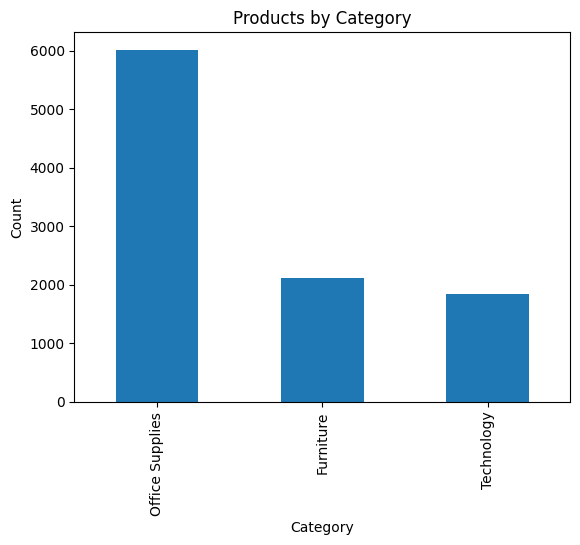

In [58]:
import matplotlib.pyplot as plt

df["category"].value_counts().plot(kind="bar")

plt.title("Products by Category")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

Office Supplies is the dominant category with more than 6000 records, followed by Furniture and Technology. This indicates that Office Supplies contributes the largest share of transactions in the dataset.

## Visualization 2: Sales Distribution

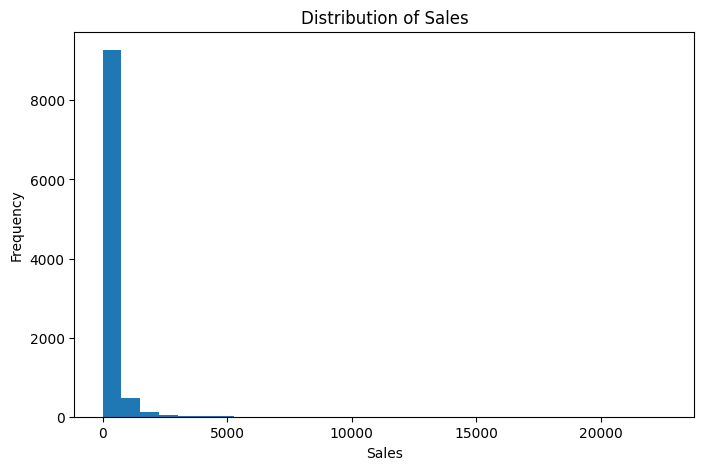

In [59]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(df["sales"], bins=30)

plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.show()

Most sales transactions are of low value, while a few transactions have very high sales values. The distribution is highly right-skewed, indicating the presence of high-value sales outliers.

## Visualization 3: Profit Distribution

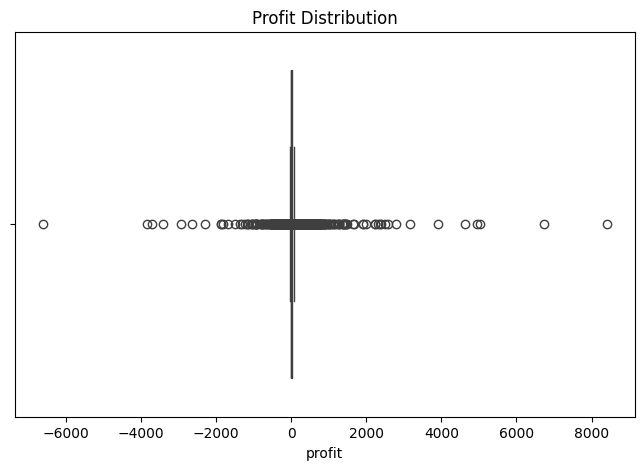

In [60]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.boxplot(x=df["profit"])

plt.title("Profit Distribution")

plt.show()

Profit contains both positive and negative values. Several extreme outliers exist, showing that some orders generate very high profits while others result in significant losses.

## Visualization 4: Correlation Heatmap

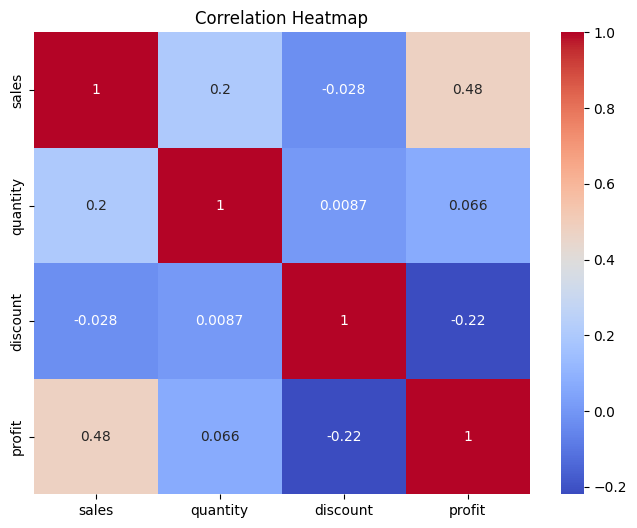

In [61]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_df = df[["sales","quantity","discount","profit"]]

plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

Sales and Profit show a moderate positive correlation (0.48), suggesting that higher sales generally lead to higher profits.

Discount and Profit have a negative correlation (-0.22), indicating that increasing discounts tends to reduce profitability.

Quantity has only a weak relationship with Sales and Profit.

## Visualization 5: Sales vs Profit

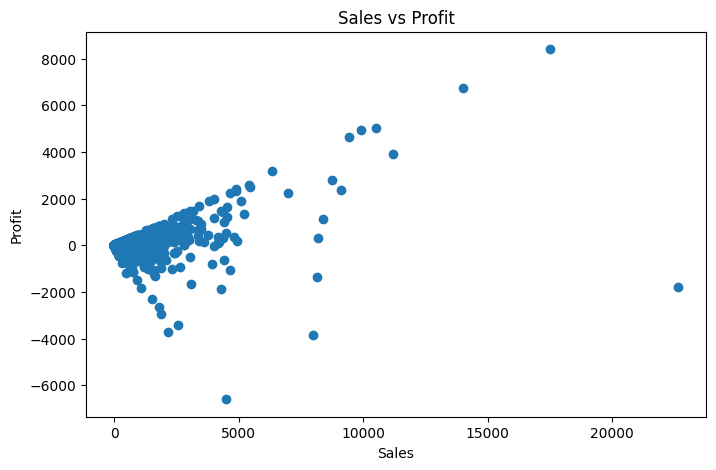

In [62]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(df["sales"], df["profit"])

plt.title("Sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")

plt.show()

Observation: 


Sales and Profit show a generally positive relationship. Higher sales tend to generate higher profits, although some high-sales transactions still result in losses due to discounts or operational factors.

# Key Findings

1. Office Supplies is the most frequently sold category.

2. Most transactions involve relatively low sales amounts.

3. Sales and Profit have a moderate positive correlation (0.48).

4. Discounts negatively affect profitability.

5. West region has the highest number of transactions.

6. Higher sales generally result in higher profits.